# Verification: `tlbr_steric_monine2010`

Trivalent-ligand / bivalent-receptor (TLBR) steric-aggregation model of
**Monine et al. (2010)**, *Biophys J* 98(1):48-56
(doi:10.1016/j.bpj.2009.09.043). A trivalent ligand crosslinks bivalent
IgE-FceRI receptors into aggregates that grow without bound, so the model is
simulated **network-free** (NFsim / RuleMonkey). Its steric constraint is that
aggregates are **acyclic** (the equivalent-site assumption), enforced by NFsim's
block-same-complex-binding (`-bscb`).

Two levels of verification (issue #11, tasks 2-3), all driven by
[`run_monine2010.py`](run_monine2010.py):

1. **Reported-data check** — the acyclic model (`-bscb`) at the Table-1 best fit
   reproduces the **Fig. 2a** binding isotherm.
2. **Independent-algorithm check** — two independent network-free algorithms,
   **NFsim** (Yang et al. 2008) and **RuleMonkey** (Colvin et al. 2009/2010), both
   with `-bscb`, agree on the per-dose equilibrium λ. Legacy NFsim *without*
   `-bscb` allows ring closure and is **not** a valid reference.

This notebook loads the committed reference data (`reference/*.npz`) and displays
the results. To regenerate everything from scratch (needs `BNGPATH` set and the
`bngsim` package):

```bash
python run_monine2010.py all      # reference + agreement + plot
```

In [1]:
import os
import numpy as np

HERE = os.getcwd()
REF = os.path.join(HERE, "reference")

# 1) Reported-data check: Fig 2a reproduction (acyclic TLBR, -bscb, Table-1 fit).
rp = np.load(os.path.join(REF, "reproduction.npz"))
print("Fig 2a reproduction (NFsim -bscb @ Monine Table 1):")
print(f"  sos (FL space)   = {float(rp['sos']):.5f}")
print(f"  RMS in lambda    = {float(rp['rms_lam']):.4f}   "
      f"(Monine kept fits RMS < 0.02, SI Eq 11)")
big = np.abs(rp['fl_data']) > 0.05
rel = np.abs(rp['fl_model'][big] - rp['fl_data'][big]) / np.abs(rp['fl_data'][big])
print(f"  median |rel err| = {np.median(rel):.3f}  (over doses with FL > 0.05)")
assert float(rp['rms_lam']) < 0.02, "RMS in lambda should be within Monine's acceptance"
print("  -> PASS: reproduces Fig 2a within Monine's own RMS < 0.02 acceptance")

Fig 2a reproduction (NFsim -bscb @ Monine Table 1):
  sos (FL space)   = 0.00278
  RMS in lambda    = 0.0124   (Monine kept fits RMS < 0.02, SI Eq 11)
  median |rel err| = 0.024  (over doses with FL > 0.05)
  -> PASS: reproduces Fig 2a within Monine's own RMS < 0.02 acceptance


In [2]:
# 2) Independent-algorithm check: three network-free engines, all -bscb.
ag = np.load(os.path.join(REF, "agreement.npz"))
doses = ag["doses"]
big = np.abs(ag["fl_data"]) > 0.05

def mean_se(A):
    return A.mean(0), A.std(0, ddof=1) / np.sqrt(A.shape[0])

labels = [("bng_nf", "BNG NFsim"), ("bngsim_nf", "bngsim NFsim"),
          ("bngsim_rm", "bngsim RuleMonkey")]
print(f"per-dose equilibrium lambda (mean +/- s.e.m.), {int(ag['n_seeds'])} seeds/engine:")
print("  dose(nM)  " + "  ".join(f"{n:>16s}" for _, n in labels))
for i in np.where(big)[0]:
    cells = []
    for k, _ in labels:
        m, se = ag[k][:, i].mean(), ag[k][:, i].std(ddof=1) / np.sqrt(ag[k].shape[0])
        cells.append(f"{m:.3f}+/-{se:.3f}")
    print(f"  {doses[i]:8.3f}  " + "  ".join(f"{c:>16s}" for c in cells))

dmax = float(ag["dmax"])
print(f"\nthree -bscb engines agree to max |d lambda| = {dmax:.4f} "
      f"(< Monine RMS 0.02)")
assert dmax < 0.02, "independent network-free engines should agree within Monte-Carlo scale"

# Contrast: dropping -bscb (rings allowed) changes the model.
m_on, _ = mean_se(ag["bngsim_nf"]); m_off, _ = mean_se(ag["bngsim_nf_nobscb"])
absbias = np.abs(m_on - m_off)[big]
print(f"-bscb vs no-bscb (bngsim NFsim): max |d lambda| = {absbias.max():.4f} "
      f"(at {doses[big][absbias.argmax()]:.3g} nM)")
print("  -> PASS: NFsim = RuleMonkey with -bscb; a no-bscb run is a different model")

per-dose equilibrium lambda (mean +/- s.e.m.), 20 seeds/engine:
  dose(nM)         BNG NFsim      bngsim NFsim  bngsim RuleMonkey
     0.151     0.150+/-0.000     0.152+/-0.000     0.152+/-0.000
     0.501     0.348+/-0.000     0.353+/-0.001     0.352+/-0.002
     1.565     0.450+/-0.001     0.452+/-0.002     0.453+/-0.002
     5.226     0.506+/-0.000     0.509+/-0.001     0.508+/-0.002
    16.902     0.594+/-0.001     0.582+/-0.003     0.586+/-0.004
    67.960     0.716+/-0.001     0.717+/-0.004     0.723+/-0.003
   213.459     0.841+/-0.001     0.840+/-0.003     0.838+/-0.002

three -bscb engines agree to max |d lambda| = 0.0111 (< Monine RMS 0.02)
-bscb vs no-bscb (bngsim NFsim): max |d lambda| = 0.0458 (at 0.501 nM)
  -> PASS: NFsim = RuleMonkey with -bscb; a no-bscb run is a different model


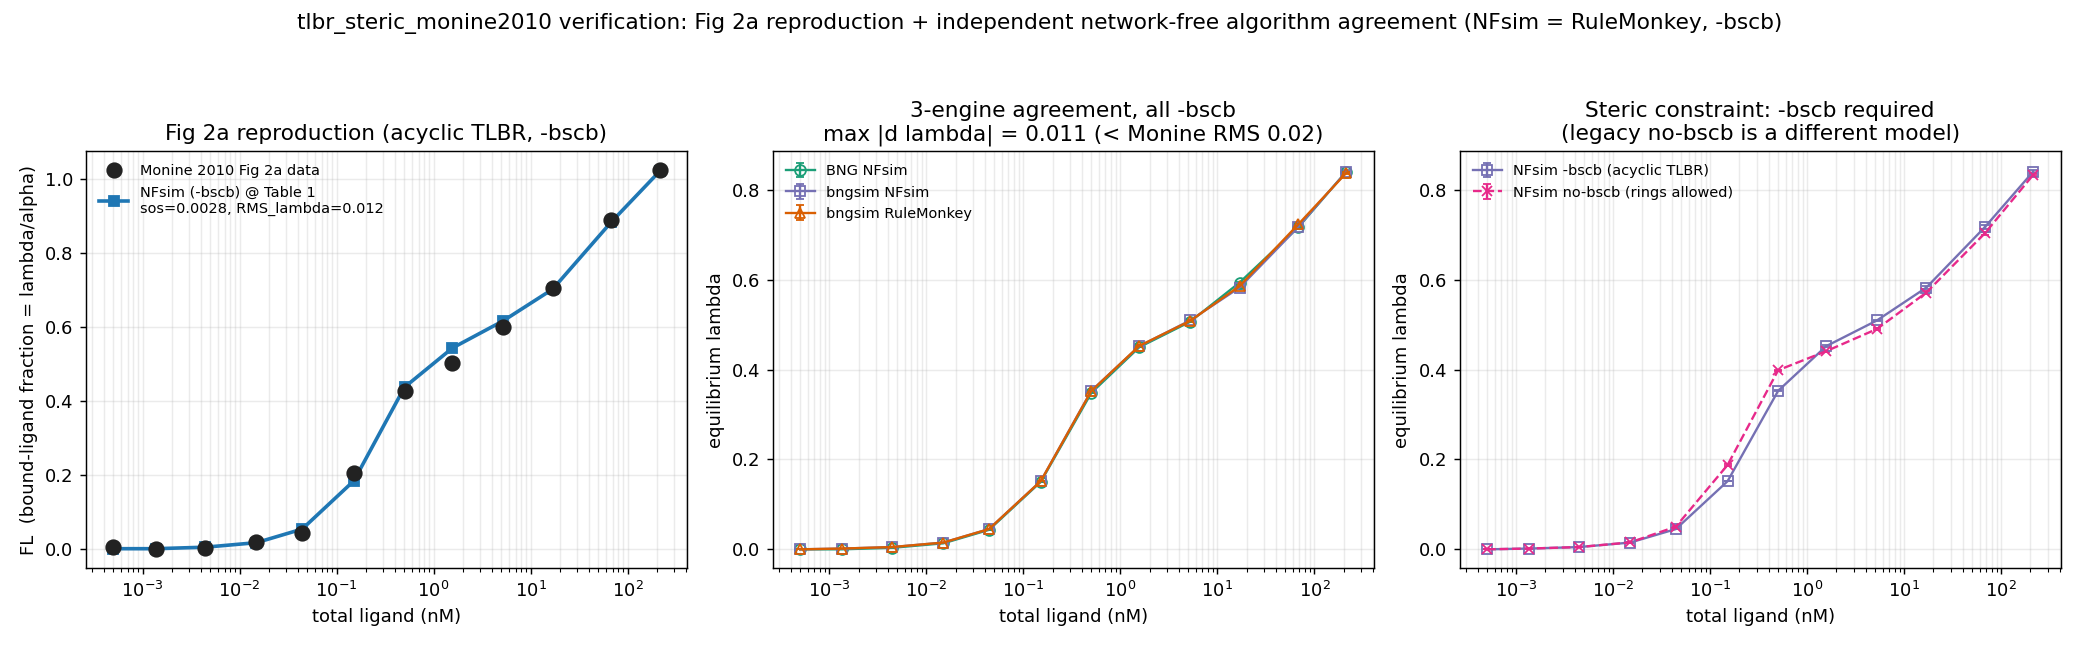

In [3]:
# Verification figure (built by run_monine2010.py plot).
from IPython.display import Image
Image(filename=os.path.join(HERE, "verify_monine2010.png"))